# Monte-Carlo simulation in X-ray data analysis

Contact: Honghui Liu (honghui.liu\<at\>uni-tuebingen.de)

In [1]:
import numpy as np
import emcee
import matplotlib.pyplot as plt
from astropy.io import fits

import matplotlib_inline
#set_matplotlib_formats('svg')
matplotlib_inline.backend_inline.set_matplotlib_formats("svg")

## Case I: Stokes parameters and uncertainties for X-ray linear polarization
(generated by ChatGPT)

In an event-based X-ray polarization analysis, each photon has a reconstructed photoelectron emission angle $\phi_i$. In this note, we use the convention **with the extra factor of 2** in the event-level Stokes parameters:

$$
i_i = 1,
$$

$$
q_i = 2\cos(2\phi_i),
$$

$$
u_i = 2\sin(2\phi_i).
$$

If event weights $w_i$ are used, the binned Stokes parameters are

$$
I = \sum_i w_i,
$$

$$
Q = \sum_i 2w_i\cos(2\phi_i),
$$

$$
U = \sum_i 2w_i\sin(2\phi_i).
$$

For unweighted events, $w_i=1$, so

$$
I=N,
$$

$$
Q = \sum_i 2\cos(2\phi_i),
$$

$$
U = \sum_i 2\sin(2\phi_i).
$$

The normalized Stokes parameters are

$$
q = \frac{Q}{I},
$$

$$
u = \frac{U}{I}.
$$

With this factor-2 convention, the measured modulation amplitude is

$$
a = \sqrt{q^2+u^2}.
$$

For a detector with modulation factor $\mu$, the polarization degree is

$$
PD = \frac{1}{\mu}\sqrt{q^2+u^2},
$$

where $\mu$ is the modulation factor. If $Q$ and $U$ have already been corrected for the modulation factor, then one can simply use

$$
PD = \sqrt{q^2+u^2}.
$$

The polarization angle is

$$
PA = \frac{1}{2}\operatorname{atan2}(u,q).
$$

The factor $1/2$ appears because linear polarization has a $180^\circ$ symmetry.

---

### Uncertainties on $I,Q,U$

For weighted events, the variances can be estimated as

$$
\sigma_I^2 = \sum_i w_i^2,
$$

$$
\sigma_Q^2 = \sum_i w_i^2 \left[2\cos(2\phi_i)\right]^2,
$$

$$
\sigma_U^2 = \sum_i w_i^2 \left[2\sin(2\phi_i)\right]^2.
$$

The covariances are

$$
{\rm Cov}(I,Q) = \sum_i 2w_i^2\cos(2\phi_i),
$$

$$
{\rm Cov}(I,U) = \sum_i 2w_i^2\sin(2\phi_i),
$$

$$
{\rm Cov}(Q,U) = \sum_i w_i^2 \left[2\cos(2\phi_i)\right]\left[2\sin(2\phi_i)\right].
$$

For unweighted events and weak polarization, the approximate results are

$$
\sigma_I^2 \simeq N,
$$

$$
\sigma_Q^2 \simeq 2N,
$$

$$
\sigma_U^2 \simeq 2N,
$$

and

$$
{\rm Cov}(I,Q) \simeq 0,
$$

$$
{\rm Cov}(I,U) \simeq 0,
$$

$$
{\rm Cov}(Q,U) \simeq 0.
$$

Therefore,

$$
\sigma_I \simeq \sqrt{N},
$$

$$
\sigma_Q \simeq \sqrt{2N},
$$

$$
\sigma_U \simeq \sqrt{2N}.
$$

---

### Uncertainties on normalized Stokes parameters $q$ and $u$

The normalized Stokes parameters are

$$
q = \frac{Q}{I},
$$

$$
u = \frac{U}{I}.
$$

Using error propagation, the variance of $q$ is

$$
\sigma_q^2 = \frac{\sigma_Q^2}{I^2} + \frac{Q^2\sigma_I^2}{I^4} - \frac{2Q}{I^3}{\rm Cov}(I,Q).
$$

Equivalently, since $q=Q/I$,

$$
\sigma_q^2 = \frac{1}{I^2}\left[\sigma_Q^2 + q^2\sigma_I^2 - 2q{\rm Cov}(I,Q)\right].
$$

Similarly,

$$
\sigma_u^2 = \frac{1}{I^2}\left[\sigma_U^2 + u^2\sigma_I^2 - 2u{\rm Cov}(I,U)\right].
$$

The covariance between $q$ and $u$ is

$$
{\rm Cov}(q,u) = \frac{1}{I^2}\left[{\rm Cov}(Q,U) - u{\rm Cov}(I,Q) - q{\rm Cov}(I,U) + qu\sigma_I^2\right].
$$

If the covariances between $I,Q,U$ are negligible, then

$$
\sigma_q^2 \simeq \frac{\sigma_Q^2}{I^2} + \frac{q^2\sigma_I^2}{I^2},
$$

$$
\sigma_u^2 \simeq \frac{\sigma_U^2}{I^2} + \frac{u^2\sigma_I^2}{I^2},
$$

$$
{\rm Cov}(q,u) \simeq \frac{qu\sigma_I^2}{I^2}.
$$

If $q\ll1$, $u\ll1$, and the source is weakly polarized, the terms involving $q^2$, $u^2$, and $qu$ are small. Then

$$
\sigma_q \simeq \frac{\sigma_Q}{I},
$$

$$
\sigma_u \simeq \frac{\sigma_U}{I}.
$$

For unweighted events with $I=N$, using the factor-2 convention,

$$
\sigma_q \simeq \sqrt{\frac{2}{N}},
$$

$$
\sigma_u \simeq \sqrt{\frac{2}{N}}.
$$

---

### Exact error propagation from $q,u$ to $PD,PA$

Define

$$
r = \sqrt{q^2+u^2}.
$$

With the factor-2 convention,

$$
PD = \frac{1}{\mu}r.
$$

For compactness, define

$$
k = \frac{1}{\mu}.
$$

Then

$$
PD = k\sqrt{q^2+u^2}.
$$

If the modulation correction has already been applied, use $k=1$.

The derivatives of $PD$ are

$$
\frac{\partial PD}{\partial q} = k\frac{q}{\sqrt{q^2+u^2}},
$$

$$
\frac{\partial PD}{\partial u} = k\frac{u}{\sqrt{q^2+u^2}}.
$$

Therefore, the propagated uncertainty on $PD$ is

$$
\sigma_{PD}^2 = k^2 \frac{q^2\sigma_q^2 + u^2\sigma_u^2 + 2qu{\rm Cov}(q,u)}{q^2+u^2}.
$$

The polarization angle is

$$
PA = \frac{1}{2}\operatorname{atan2}(u,q).
$$

The derivatives are

$$
\frac{\partial PA}{\partial q} = -\frac{1}{2}\frac{u}{q^2+u^2},
$$

$$
\frac{\partial PA}{\partial u} = \frac{1}{2}\frac{q}{q^2+u^2}.
$$

Therefore, the propagated uncertainty on $PA$ is

$$
\sigma_{PA}^2 = \frac{1}{4(q^2+u^2)^2}\left[u^2\sigma_q^2 + q^2\sigma_u^2 - 2qu{\rm Cov}(q,u)\right].
$$

This gives $\sigma_{PA}$ in radians. To convert to degrees,

$$
\sigma_{PA,{\rm deg}} = \sigma_{PA,{\rm rad}}\frac{180^\circ}{\pi}.
$$

---

### High-significance approximation

At high significance, the posterior in the $q-u$ plane is approximately Gaussian and far from the origin. If

$$
\sigma_q = \sigma_u = \sigma,
$$

and

$$
{\rm Cov}(q,u)=0,
$$

then the uncertainty on

$$
r = \sqrt{q^2+u^2}
$$

is approximately

$$
\sigma_r \simeq \sigma.
$$

Since

$$
PD = kr,
$$

the uncertainty on $PD$ is

$$
\sigma_{PD} \simeq k\sigma.
$$

For the factor-2 convention,

$$
k = \frac{1}{\mu},
$$

so

$$
\sigma_{PD} \simeq \frac{1}{\mu}\sigma.
$$

If the data products are already corrected so that $PD=\sqrt{q^2+u^2}$, then $k=1$, and

$$
\sigma_{PD} \simeq \sigma.
$$

For the polarization angle, the high-significance approximation gives

$$
\sigma_{PA} \simeq \frac{1}{2}\frac{\sigma}{\sqrt{q^2+u^2}}.
$$

Since

$$
PD = k\sqrt{q^2+u^2},
$$

this can also be written as

$$
\sigma_{PA} \simeq \frac{1}{2}\frac{\sigma_{PD}}{PD}.
$$

This expression is in radians. In degrees,

$$
\sigma_{PA,{\rm deg}} \simeq \frac{1}{2}\frac{\sigma_{PD}}{PD}\frac{180^\circ}{\pi}.
$$

Numerically,

$$
\sigma_{PA,{\rm deg}} \simeq 28.65^\circ\left(\frac{\sigma_{PD}}{PD}\right).
$$

Thus, for example, if

$$
PD = 4%,
$$

and

$$
\sigma_{PD} = 1%,
$$

then

$$
\sigma_{PA} \simeq 28.65^\circ\frac{1}{4} \simeq 7.2^\circ.
$$

---

### Important caveat at low significance

The high-significance approximation is valid only when the measured polarization is well separated from the origin in the $q-u$ plane. When

$$
\frac{PD}{\sigma_{PD}} \lesssim 2,
$$

the distribution of $PD$ becomes non-Gaussian and biased upward because

$$
PD \geq 0.
$$

The polarization angle may also become poorly constrained because $PA$ is undefined at

$$
q=u=0.
$$

Therefore, at low significance, it is better to perform statistical inference in the $q-u$ plane, or equivalently in the $I,Q,U$ space, and then transform the posterior samples to $PD$ and $PA$.


In [2]:
# ============================================================
# Basic polarization relations
# ============================================================

def qu_from_pdpa(pd, pa_deg):
    """
    Convert polarization degree and angle to normalized Stokes q,u.

    PA is in degrees.
    q = PD cos(2 PA)
    u = PD sin(2 PA)
    """
    pa = np.deg2rad(pa_deg)
    q = pd * np.cos(2.0 * pa)
    u = pd * np.sin(2.0 * pa)
    return q, u


def pdpa_from_qu(q, u):
    """
    Convert normalized Stokes q,u to polarization degree and angle.

    PD = sqrt(q^2 + u^2)
    PA = 0.5 atan2(u, q)

    PA is returned in degrees in the range [-90, 90).
    """
    pd = np.sqrt(q**2 + u**2)
    pa = 0.5 * np.rad2deg(np.arctan2(u, q))

    # Optional: keep PA in [-90, 90)
    pa = ((pa + 90.0) % 180.0) - 90.0

    return pd, pa


# ============================================================
# Gaussian likelihood in q,u
# ============================================================

def log_likelihood_qu(theta, q_obs, u_obs, cov):
    """
    Gaussian likelihood in the measured q,u plane.

    theta = [q, u]
    """
    q, u = theta
    diff = np.array([q - q_obs, u - u_obs])
    inv_cov = np.linalg.inv(cov)
    #return -0.5 * diff @ inv_cov @ diff 
    return -0.5 * np.dot(diff, np.linalg.solve(cov, diff))


def log_prior_qu(theta):
    """
    Simple broad physical prior.

    We require PD <= 1.
    For most X-ray polarization measurements this boundary is irrelevant.
    """
    q, u = theta
    pd = np.sqrt(q**2 + u**2)

    if pd <= 1.0:
        return 0.0
    else:
        return -np.inf


def log_posterior_qu(theta, q_obs, u_obs, cov):
    lp = log_prior_qu(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood_qu(theta, q_obs, u_obs, cov)

In [3]:
def run_emcee_mcmc(
    q_obs,
    u_obs,
    cov,
    n_walkers=32,
    n_steps=10000,
    burn=2000,
    seed=1,
):
    """
    Run an emcee ensemble MCMC chain in q,u.

    Parameters
    ----------
    q_obs, u_obs : float
        Observed normalized Stokes parameters.

    cov : 2x2 array
        Covariance matrix of q,u.

    n_walkers : int
        Number of emcee walkers. Should be at least 2 * ndim.
        Here ndim = 2, so n_walkers >= 4, but 32 or 64 is safer.

    n_steps : int
        Number of MCMC steps per walker.

    burn : int
        Number of initial steps to discard.

    seed : int
        Random seed.

    Returns
    -------
    samples : array
        Flattened post-burn-in samples with shape
        ((n_steps - burn) * n_walkers, 2).

    logp : array
        Flattened log posterior values.

    sampler : emcee.EnsembleSampler
        The full emcee sampler object.
    """

    rng = np.random.default_rng(seed)

    ndim = 2

    # --------------------------------------------------------
    # Initial walker positions
    # --------------------------------------------------------
    # Start walkers around the observed q,u point.
    # The scatter is chosen from the measurement covariance.
    p0 = rng.multivariate_normal(
        mean=np.array([q_obs, u_obs]),
        cov=cov,
        size=n_walkers,
    )

    # Make sure initial walkers satisfy the physical prior PD <= 1
    for i in range(n_walkers):
        pd = np.sqrt(p0[i, 0]**2 + p0[i, 1]**2)

        while pd > 1.0:
            p0[i] = rng.multivariate_normal(
                mean=np.array([q_obs, u_obs]),
                cov=cov,
            )
            pd = np.sqrt(p0[i, 0]**2 + p0[i, 1]**2)

    # --------------------------------------------------------
    # Build and run emcee sampler
    # --------------------------------------------------------
    sampler = emcee.EnsembleSampler(
        n_walkers,
        ndim,
        log_posterior_qu,
        args=(q_obs, u_obs, cov),
    )

    sampler.run_mcmc(p0, n_steps, progress=False)

    # --------------------------------------------------------
    # Extract post-burn-in samples
    # --------------------------------------------------------
    samples = sampler.get_chain(discard=burn, flat=True)
    logp = sampler.get_log_prob(discard=burn, flat=True)

    try:
        tau = sampler.get_autocorr_time()
        print("Autocorrelation time:", tau)
        print("Chain length / tau:", 10000 / tau)
    except emcee.autocorr.AutocorrError as e:
        print("Autocorrelation time estimate failed:")
        print(e)

    return samples, logp, sampler

# ============================================================
# Simple Metropolis-Hastings MCMC sampler
# ============================================================

def run_mh_mcmc(
    q_obs,
    u_obs,
    cov,
    n_steps=100_000,
    burn=20_000,
    proposal_scale=1.0,
    seed=1,
):
    """
    Run a simple Metropolis-Hastings chain in q,u.

    The proposal is a Gaussian centered on the current point.
    proposal_cov = proposal_scale^2 * cov
    """

    rng = np.random.default_rng(seed)

    proposal_cov = proposal_scale**2 * cov

    chain = np.zeros((n_steps, 2))
    logp = np.zeros(n_steps)

    # Start at the observed point
    current = np.array([q_obs, u_obs])
    current_logp = log_posterior_qu(current, q_obs, u_obs, cov)

    n_accept = 0

    for i in range(n_steps):
        proposal = rng.multivariate_normal(current, proposal_cov)
        proposal_logp = log_posterior_qu(proposal, q_obs, u_obs, cov)

        log_alpha = proposal_logp - current_logp

        if np.log(rng.uniform()) < log_alpha:
            current = proposal
            current_logp = proposal_logp
            n_accept += 1

        chain[i] = current
        logp[i] = current_logp

    samples = chain[burn:]
    acceptance = n_accept / n_steps

    return samples, logp, acceptance


# ============================================================
# One experiment: simulate q,u measurement and run MCMC
# ============================================================

def run_case(label, pd_true, pa_true_deg, sigma_q, sigma_u, rho=0.0, seed=1.0):
    """
    Simulate one measurement and run MCMC.

    sigma_q and sigma_u are uncertainties on normalized q,u.

    rho=0.0: covariance between q and u is zero.
    """

    rng = np.random.default_rng(seed)

    q_true, u_true = qu_from_pdpa(pd_true, pa_true_deg)

    q_obs, u_obs = q_true, u_true

    ## The covariance matrix between q and u
    ## Here q and u are assumed to be independent
    cov = np.array([
        [sigma_q**2, rho * sigma_q * sigma_u],
        [rho * sigma_q * sigma_u, sigma_u**2],
    ])


    samples_qu, logp, sampler = run_emcee_mcmc(
    q_true,
    u_true,
    cov,
    n_walkers=32,
    n_steps=10000,
    burn=2000,
    seed=seed + 100,
)

    q_samp = samples_qu[:, 0]
    u_samp = samples_qu[:, 1]

    pd_samp, pa_samp = pdpa_from_qu(q_samp, u_samp)
    pd_obs, pa_obs = pdpa_from_qu(q_obs, u_obs)

    return {
        "label": label,
        "pd_true": pd_true,
        "pa_true_deg": pa_true_deg,
        "q_true": q_true,
        "u_true": u_true,
        "q_obs": q_true,
        "u_obs": u_true,
        "pd_obs": pd_true,
        "pa_obs": pa_true,
        "cov": cov,
        "samples_qu": samples_qu,
        "pd_samples": pd_samp,
        "pa_samples": pa_samp,
        #"acceptance": acc,
        "acceptance": np.mean(sampler.acceptance_fraction),
        "sigma_q": sigma_q,
        "sigma_u": sigma_u,
    }

In [4]:
# ============================================================
# Plotting helpers
# ============================================================

def plot_qu_panel(ax, q_obs, u_obs, cov, samples, title):
    """
    Plot posterior samples in q,u plane.
    """

    ax.scatter(samples[::20, 0], samples[::20, 1], s=2, alpha=0.15, color="grey")
    ax.scatter(q_obs, u_obs, marker="x", s=80, label="Observed")
    ax.scatter(0, 0, marker="+", s=80, label="Unpolarized")

    # Draw 1, 2, 3 sigma Gaussian contours
    eigvals, eigvecs = np.linalg.eigh(cov)
    angles = np.linspace(0, 2 * np.pi, 400)

    for nsig in [1, 2, 3]:
        circle = np.vstack([np.cos(angles), np.sin(angles)])
        ellipse = eigvecs @ np.diag(np.sqrt(eigvals)) @ circle
        ellipse *= nsig
        ax.plot(q_obs + ellipse[0], u_obs + ellipse[1], lw=1)

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(r"$q = Q/I$")
    ax.set_ylabel(r"$u = U/I$")
    ax.set_title(title)
    ax.legend(fontsize=8)


def plot_pdpa_panel(ax, pd_samples, pa_samples, pd_obs, pa_obs,
                    sigma_pd_simple=None, sigma_pa_simple=None,
                    title=""):
    """
    Plot transformed posterior samples in PD, PA plane.
    """

    ax.scatter(100 * pd_samples[::20], pa_samples[::20], s=2, alpha=0.15, color="grey")
    ax.scatter(100 * pd_obs, pa_obs, marker="x", s=80, label="Observed")

    if sigma_pd_simple is not None and sigma_pa_simple is not None:
        ax.errorbar(
            100 * pd_obs,
            pa_obs,
            xerr=100 * sigma_pd_simple,
            yerr=sigma_pa_simple,
            fmt="o",
            capsize=4,
            label="High-S/N analytic approx.",
        )

    ax.set_xlabel(r"$PD$ [%]")
    ax.set_ylabel(r"$PA$ [deg]")
    ax.set_title(title)
    ax.legend(fontsize=8)

def plot_pdpa_polar_panel(
    ax,
    pd_samples,
    pa_samples,
    pd_obs,
    pa_obs,
    sigma_pd_simple=None,
    sigma_pa_simple=None,
    title="",
):
    """
    Plot the transformed posterior in the PD-PA plane using polar coordinates.

    Radius:
        r = PD

    Polar angle:
        theta = 2 PA

    This is the most natural convention for linear polarization because
        q = PD cos(2 PA)
        u = PD sin(2 PA)

    PA is shown on the angular labels, but internally the polar angle is 2 PA.
    """

    # Convert PA to plotting angle theta = 2 PA
    theta_samples = np.deg2rad(2.0 * pa_samples)
    theta_obs = np.deg2rad(2.0 * pa_obs)

    # Scatter posterior samples
    ax.scatter(
        theta_samples[::20],
        100.0 * pd_samples[::20],
        s=2,
        alpha=0.15,
        color="grey",
    )

    # Observed point
    ax.scatter(
        theta_obs,
        100.0 * pd_obs,
        marker="x",
        s=80,
        label="Observed",
    )

    # Optional high-significance analytic approximation
    if sigma_pd_simple is not None and sigma_pa_simple is not None:
        # Draw approximate 1-sigma ellipse in local PD-PA coordinates
        t = np.linspace(0, 2 * np.pi, 300)

        pd_ellipse = pd_obs + sigma_pd_simple * np.cos(t)
        pa_ellipse = pa_obs + sigma_pa_simple * np.sin(t)

        theta_ellipse = np.deg2rad(2.0 * pa_ellipse)

        ax.plot(
            theta_ellipse,
            100.0 * pd_ellipse,
            lw=2,
            label="High-S/N analytic approx.",
        )

    ax.set_title(title)

    # Radius label
    ax.set_ylabel("PD [%]")

    # Show PA labels instead of raw 2PA labels
    # The polar coordinate angle is 2PA, but the tick labels are PA.
    pa_tick_labels = np.array([-90, -60, -30, 0, 30, 60, 90])
    theta_tick_positions = np.deg2rad(2.0 * pa_tick_labels)

    # Convert to [0, 2pi)
    theta_tick_positions = theta_tick_positions % (2.0 * np.pi)

    ax.set_xticks(theta_tick_positions)
    ax.set_xticklabels([f"{pa:d}°" for pa in pa_tick_labels])

    ax.set_theta_zero_location("E")
    ax.set_theta_direction(1)

    ax.grid(True)
    ax.legend(fontsize=8, loc="upper right")

def plot_pd_1d_panel(ax, pd_samples, pd_obs, sigma_pd_simple=None, title=""):
    """
    Plot the 1D posterior distribution of PD.
    """

    ax.hist(
        100.0 * pd_samples,
        bins=60,
        density=True,
        histtype="step",
        lw=2,
    )

    ax.axvline(
        100.0 * pd_obs,
        ls="--",
        lw=2,
        label="Observed",
    )

    # Median and 68% credible interval
    pd_med = np.percentile(pd_samples, 50.0)
    pd_lo, pd_hi = np.percentile(pd_samples, [16.0, 84.0])

    ax.axvline(100.0 * pd_med, lw=2, label="Median")
    ax.axvspan(
        100.0 * pd_lo,
        100.0 * pd_hi,
        alpha=0.2,
        label="68% interval",
    )

    # Optional high-significance Gaussian approximation
    if sigma_pd_simple is not None:
        x = np.linspace(
            max(0.0, 100.0 * (pd_obs - 5.0 * sigma_pd_simple)),
            100.0 * (pd_obs + 5.0 * sigma_pd_simple),
            500,
        )

        mu = 100.0 * pd_obs
        sig = 100.0 * sigma_pd_simple

        y = np.exp(-0.5 * ((x - mu) / sig) ** 2)
        y /= np.trapz(y, x)

        ax.plot(
            x,
            y,
            ls=":",
            lw=2,
            label="High-S/N Gaussian",
        )

    ax.set_xlabel("PD [%]")
    ax.set_ylabel("Probability density")
    ax.set_title(title)
    ax.legend(fontsize=8)


def plot_pa_1d_panel(ax, pa_samples, pa_obs, sigma_pa_simple=None, title=""):
    """
    Plot the 1D posterior distribution of PA.

    PA is assumed to be in degrees in the range [-90, 90).
    """

    ax.hist(
        pa_samples,
        bins=60,
        density=True,
        histtype="step",
        lw=2,
    )

    ax.axvline(
        pa_obs,
        ls="--",
        lw=2,
        label="Observed",
    )

    # Median and 68% credible interval
    # This simple percentile calculation is fine when PA is localized
    # and does not wrap around the -90/90 boundary.
    pa_med = np.percentile(pa_samples, 50.0)
    pa_lo, pa_hi = np.percentile(pa_samples, [16.0, 84.0])

    ax.axvline(pa_med, lw=2, label="Median")
    ax.axvspan(
        pa_lo,
        pa_hi,
        alpha=0.2,
        label="68% interval",
    )

    # Optional high-significance Gaussian approximation
    if sigma_pa_simple is not None:
        x = np.linspace(
            pa_obs - 5.0 * sigma_pa_simple,
            pa_obs + 5.0 * sigma_pa_simple,
            500,
        )

        mu = pa_obs
        sig = sigma_pa_simple

        y = np.exp(-0.5 * ((x - mu) / sig) ** 2)
        y /= np.trapz(y, x)

        ax.plot(
            x,
            y,
            ls=":",
            lw=2,
            label="High-S/N Gaussian",
        )

    ax.set_xlabel("PA [deg]")
    ax.set_ylabel("Probability density")
    ax.set_title(title)
    ax.legend(fontsize=8)

In [5]:
# ============================================================
# Simulate a high-significance and a low-significance cases
# based on observed PD and PA. It can be adpated to work 
# directly from the observed q and u.
# ============================================================

if __name__ == "__main__":

    # True source polarization
    pd_true = 0.04       # 4%
    pa_true = 30.0       # degrees

    # High-significance case:
    # PD / sigma_PD approximately 8
    high = run_case(
        label="High significance",
        pd_true=pd_true,
        pa_true_deg=pa_true,
        sigma_q=0.005,
        sigma_u=0.005,
        rho=0.0,
        seed=10,
    )

    # Low-significance case:
    # PD / sigma_PD approximately 1--2
    low = run_case(
        label="Low significance",
        pd_true=pd_true,
        pa_true_deg=pa_true,
        sigma_q=0.020,
        sigma_u=0.020,
        rho=0.0,
        seed=20,
    )

    cases = [low, high]

Autocorrelation time: [33.36116454 31.64990166]
Chain length / tau: [299.74972812 315.95674794]
Autocorrelation time: [31.99882682 30.95599122]
Chain length / tau: [312.51145724 323.03924397]


In [6]:
# ========================================================
# Plot the sample on the q-u plane and the PD-PA plane
# ========================================================

fig = plt.figure(figsize=(10, 8))

axes = np.empty((2, 2), dtype=object)

axes[0, 0] = fig.add_subplot(2, 2, 1)
axes[0, 1] = fig.add_subplot(2, 2, 2, projection="polar")

axes[1, 0] = fig.add_subplot(2, 2, 3)
axes[1, 1] = fig.add_subplot(2, 2, 4, projection="polar")


for row, case in enumerate(cases):

    q_obs = case["q_obs"]
    u_obs = case["u_obs"]
    q_true = case["q_true"]
    u_true = case["u_true"]
    cov = case["cov"]
    samples_qu = case["samples_qu"]

    pd_obs = case["pd_obs"]
    pa_obs = case["pa_obs"]
    pa_true_deg = case["pa_true_deg"]
    pd_samples = case["pd_samples"]
    pa_samples = case["pa_samples"]

    sigma_q = case["sigma_q"]
    sigma_u = case["sigma_u"]

    # High-significance simplified approximation
    if np.isclose(sigma_q, sigma_u):
        sigma = sigma_q
        sigma_pd_simple = sigma
        sigma_pa_simple_rad = 0.5 * sigma / pd_obs
        sigma_pa_simple_deg = np.rad2deg(sigma_pa_simple_rad)
    else:
        sigma_pd_simple = None
        sigma_pa_simple_deg = None

    plot_qu_panel(
        axes[row, 0],
        q_true,
        u_true,
        cov,
        samples_qu,
        title=f"{case['label']}: posterior in q-u plane",
    )

    plot_pdpa_polar_panel(
        axes[row, 1],
        pd_samples,
        pa_samples,
        pd_true,
        pa_true_deg,
        sigma_pd_simple=sigma_pd_simple,
        sigma_pa_simple=sigma_pa_simple_deg,
        title=f"{case['label']}: polar PD-PA posterior",
    )

axes[0, 0].set_xlim(-0.1, 0.15)
axes[1, 0].set_xlim(-0.1, 0.15)

axes[0, 0].set_ylim(-0.05, 0.15)
axes[1, 0].set_ylim(-0.05, 0.15)


plt.tight_layout()
plt.show()

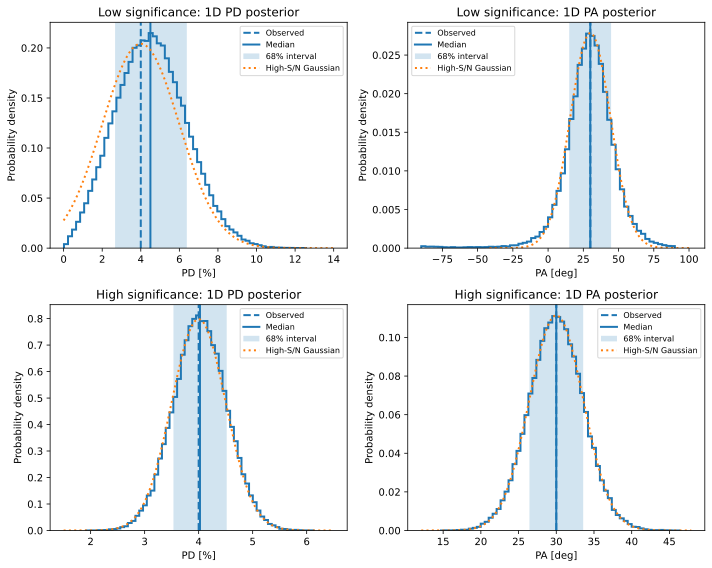

In [7]:
# ========================================================
# Plot 1D distribution for PD and PA
# ========================================================

plt.close("all")

fig = plt.figure(figsize=(10, 8))

axes = np.empty((2, 2), dtype=object)

axes[0, 0] = fig.add_subplot(2, 2, 1)
axes[0, 1] = fig.add_subplot(2, 2, 2)

axes[1, 0] = fig.add_subplot(2, 2, 3)
axes[1, 1] = fig.add_subplot(2, 2, 4)


for row, case in enumerate(cases):

    q_obs = case["q_obs"]
    u_obs = case["u_obs"]
    cov = case["cov"]
    samples_qu = case["samples_qu"]

    pd_obs = case["pd_obs"]
    pa_obs = case["pa_obs"]
    pd_samples = case["pd_samples"]
    pa_samples = case["pa_samples"]

    sigma_q = case["sigma_q"]
    sigma_u = case["sigma_u"]

    # High-significance simplified approximation
    if np.isclose(sigma_q, sigma_u):
        sigma = sigma_q
        sigma_pd_simple = sigma
        sigma_pa_simple_rad = 0.5 * sigma / pd_obs
        sigma_pa_simple_deg = np.rad2deg(sigma_pa_simple_rad)
    else:
        sigma_pd_simple = None
        sigma_pa_simple_deg = None

    plot_pd_1d_panel(
        axes[row, 0],
        pd_samples,
        pd_true,
        sigma_pd_simple=sigma_pd_simple,
        title=f"{case['label']}: 1D PD posterior",
    )

    plot_pa_1d_panel(
        axes[row, 1],
        pa_samples,
        pa_true_deg,
        sigma_pa_simple=sigma_pa_simple_deg,
        title=f"{case['label']}: 1D PA posterior",
    )


plt.tight_layout()
plt.show()

In [8]:
# ========================================================
# Print numerical summaries
# ========================================================

for case in cases:
    pd_samples = case["pd_samples"]
    pa_samples = case["pa_samples"]

    pd_med = np.median(pd_samples)
    pd_lo, pd_hi = np.percentile(pd_samples, [16, 84])

    pa_med = np.median(pa_samples)
    pa_lo, pa_hi = np.percentile(pa_samples, [16, 84])

    pd_obs = case["pd_obs"]
    pa_obs = case["pa_obs"]

    sigma = case["sigma_q"]

    # Simple high-S/N formula
    sigma_pd_simple = sigma
    sigma_pa_simple_deg = np.rad2deg(0.5 * sigma / pd_obs)

    print()
    print("=" * 70)
    print(case["label"])
    print("=" * 70)
    print(f"Acceptance fraction = {case['acceptance']:.3f}")
    print(f"Observed q = {case['q_obs']:.5f}")
    print(f"Observed u = {case['u_obs']:.5f}")
    print(f"Observed PD = {100 * pd_obs:.2f} %")
    print(f"Observed PA = {pa_obs:.2f} deg")
    print()
    print("MCMC transformed posterior:")
    print(f"PD = {100 * pd_med:.2f} +{100 * (pd_hi - pd_med):.2f} -{100 * (pd_med - pd_lo):.2f} %")
    print(f"PA = {pa_med:.2f} +{pa_hi - pa_med:.2f} -{pa_med - pa_lo:.2f} deg")
    print()
    print("Simplified high-significance approximation:")
    print(f"sigma_PD ≈ {100 * sigma_pd_simple:.2f} %")
    print(f"sigma_PA ≈ {sigma_pa_simple_deg:.2f} deg")


Low significance
Acceptance fraction = 0.715
Observed q = 0.02000
Observed u = 0.03464
Observed PD = 4.00 %
Observed PA = 30.00 deg

MCMC transformed posterior:
PD = 4.50 +1.89 -1.83 %
PA = 29.94 +14.77 -14.94 deg

Simplified high-significance approximation:
sigma_PD ≈ 2.00 %
sigma_PA ≈ 14.32 deg

High significance
Acceptance fraction = 0.715
Observed q = 0.02000
Observed u = 0.03464
Observed PD = 4.00 %
Observed PA = 30.00 deg

MCMC transformed posterior:
PD = 4.02 +0.49 -0.49 %
PA = 30.00 +3.57 -3.56 deg

Simplified high-significance approximation:
sigma_PD ≈ 0.50 %
sigma_PA ≈ 3.58 deg


## Case II: XSPEC spectral fitting with MCMC

### How MCMC works in XSPEC

<img src="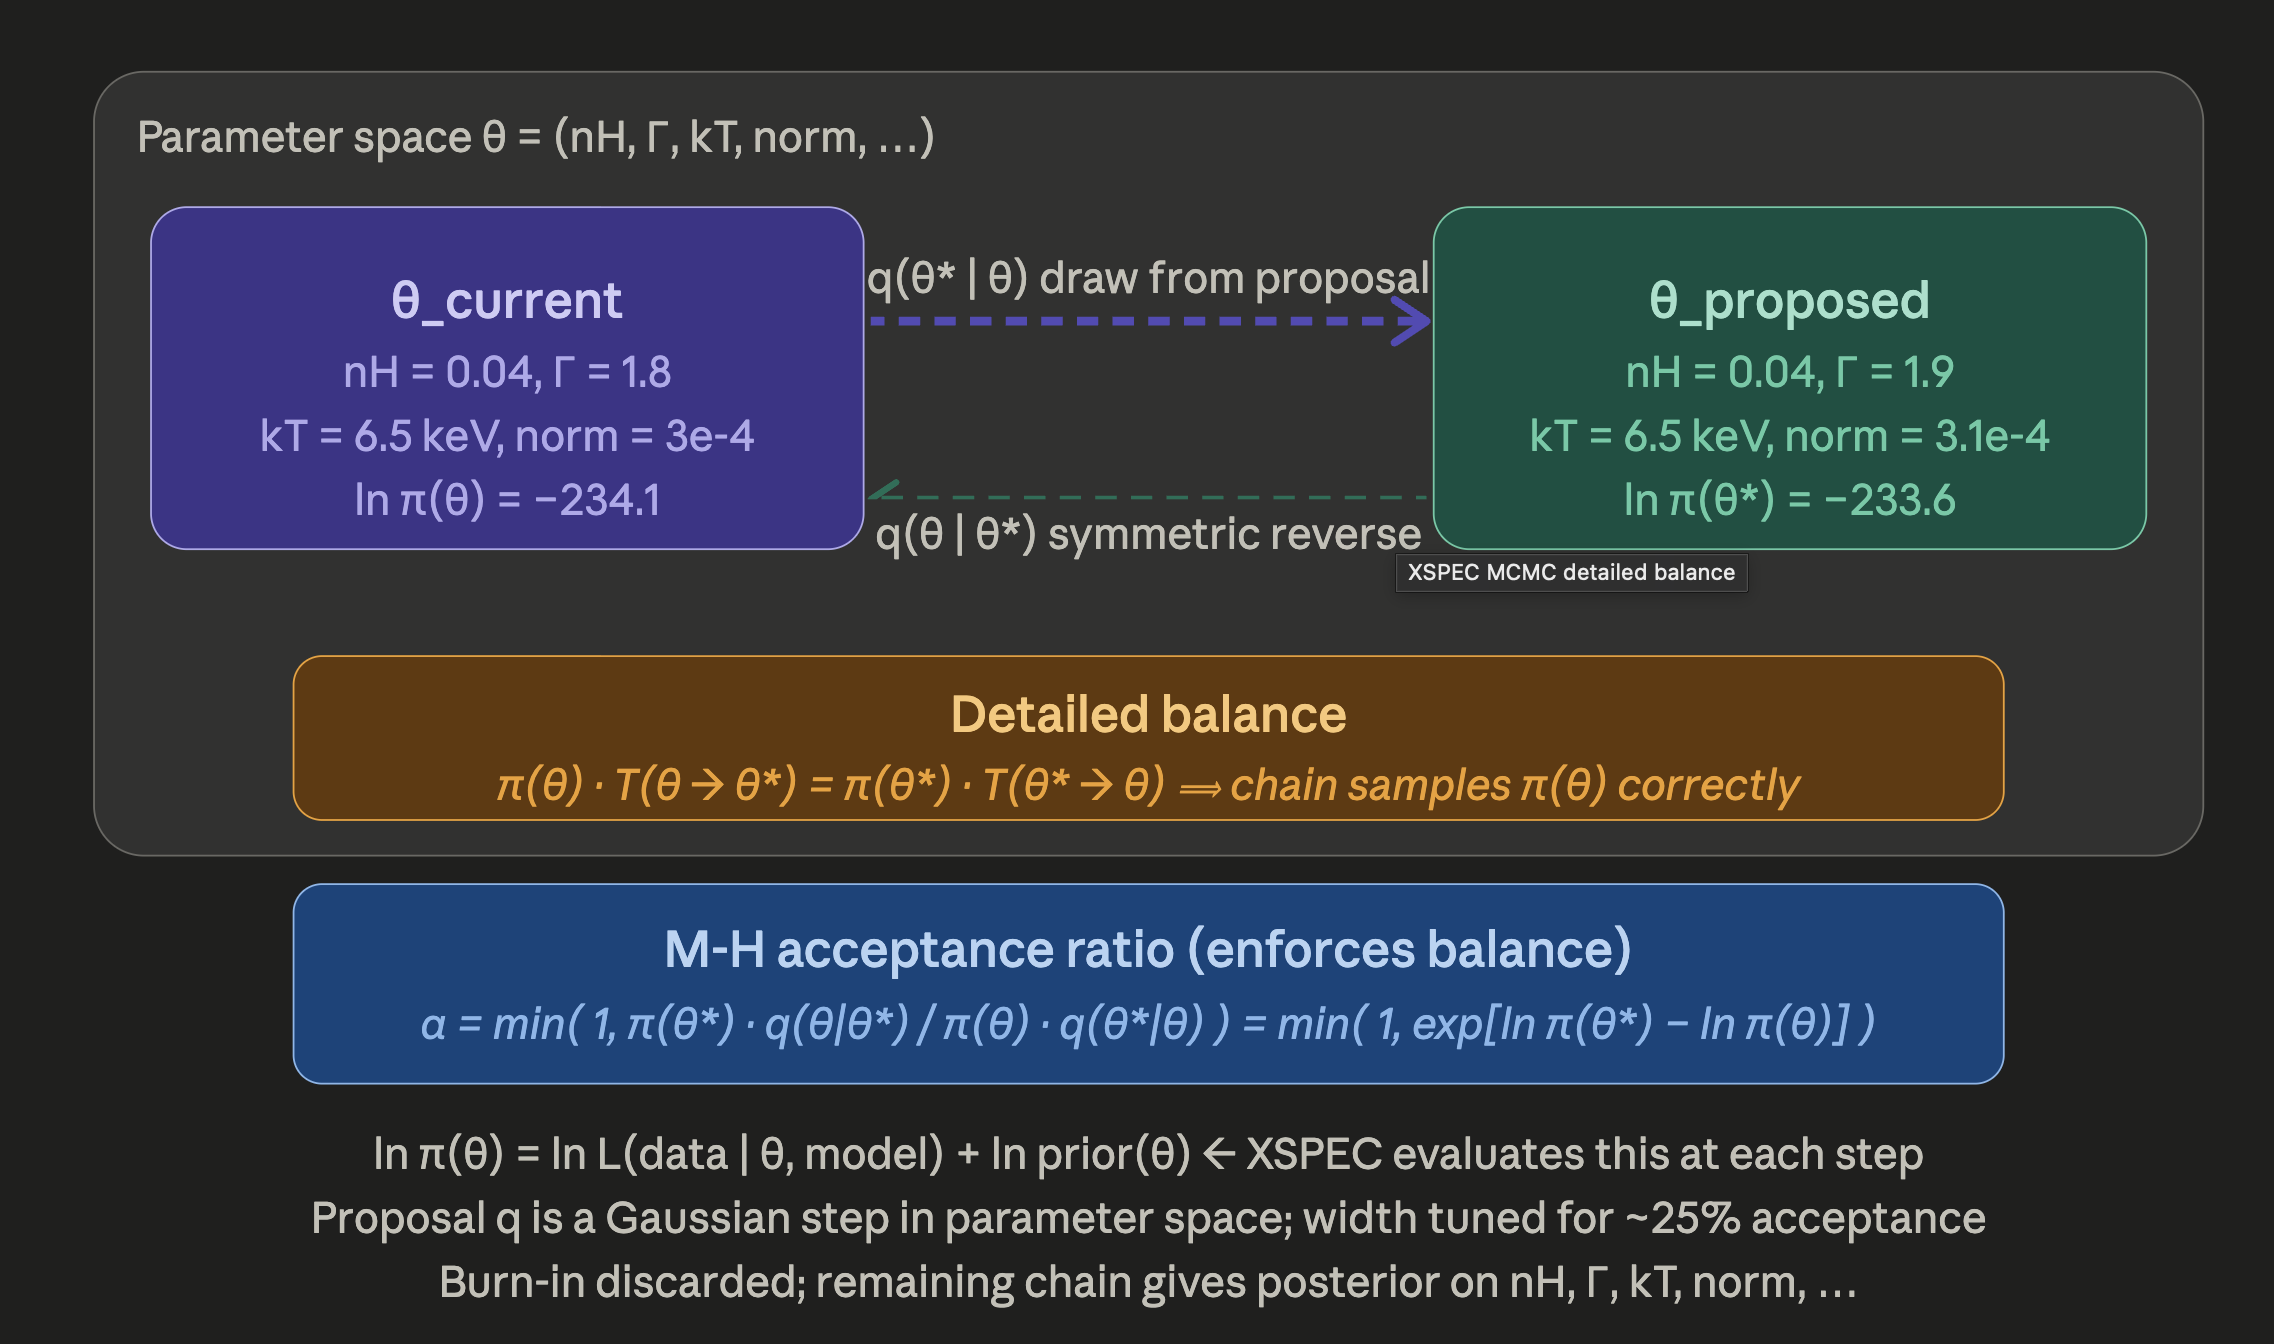
" alt="My plot" width="800"/>

**For gaussian-noise data:**

$$
\begin{aligned}
\mathcal{\pi}(\{X_i\}) &= \prod_{i=1}^{N} \mathcal{N}(X_i, M_i, \sigma_i) \\
                     &= \prod_{i=1}^{N} \frac{1}{\sqrt{2 \pi}\sigma_i} \exp (-\frac{(X_i - M_i)^2}{2 \sigma^2})
\end{aligned}
$$

$$
\begin{aligned}
-2 \ln\mathcal{\pi}(\{X_i\}, M_i\{\theta\}) &= \sum_{i=1}^{N}\frac{(X_i - M_i)^2}{\sigma_i^2} - 2\sum_{i=1}^{N} \ln \frac{1}{\sigma_i \sqrt{2 \pi}} \\
                           &= S^2 - 2\sum_{i=1}^{N} \ln \frac{1}{\sigma_i \sqrt{2 \pi}}
\end{aligned}
$$

The second term is independent of the model. Therefore, maximizing $\mathcal{\pi}(\{X_i\})$ is equivalent minimizing the quantity:

$$
S^2 = \sum_{i=1}^{N}\frac{(X_i - M_i)^2}{\sigma_i^2}
$$

In [9]:
import xspec
from astropy.io import fits
import os

ModuleNotFoundError: No module named 'xspec'

---
### Build a diagonal RMF and flat ARF

A **diagonal RMF** maps each true energy bin directly to the same PI channel — perfect energy resolution, no redistribution. This is the simplest valid response and lets us focus on the statistics rather than detector effects.

The **ARF** is set to 1000 cm² across all channels (flat effective area).

In [ ]:

# ── Energy grid ─────────────────────────────────────────────────────────────
E_MIN = 0.3       # keV
E_MAX = 10.0      # keV
N_CH  = 300       # number of channels

# One continuous edge grid with N_CH + 1 edges
E_edges = np.linspace(E_MIN, E_MAX, N_CH + 1, dtype=np.float64)

# Lower and upper channel boundaries
ENERG_LO = E_edges[:-1].astype(np.float32)
ENERG_HI = E_edges[1:].astype(np.float32)

# Channel midpoints
E_MID = 0.5 * (ENERG_LO + ENERG_HI)

print(f"Energy grid: {N_CH} channels  {ENERG_LO[0]:.2f}–{ENERG_HI[-1]:.2f} keV")
print("Grid continuous?", np.allclose(ENERG_HI[:-1], ENERG_LO[1:]))

# ── Build ARF: flat 1000 cm^2 ───────────────────────────────────────────────
arf_file = "diag.arf"

arf_cols = [
    fits.Column(name="ENERG_LO", format="E", array=ENERG_LO, unit="keV"),
    fits.Column(name="ENERG_HI", format="E", array=ENERG_HI, unit="keV"),
    fits.Column(
        name="SPECRESP",
        format="E",
        array=np.full(N_CH, 1000.0, dtype=np.float32),
        unit="cm**2",
    ),
]

arf_hdu = fits.BinTableHDU.from_columns(arf_cols)
arf_hdu.header["EXTNAME"]  = "SPECRESP"
arf_hdu.header["TELESCOP"] = "SIMSAT"
arf_hdu.header["INSTRUME"] = "DIAG"
arf_hdu.header["FILTER"]   = "NONE"
arf_hdu.header["HDUCLASS"] = "OGIP"
arf_hdu.header["HDUCLAS1"] = "RESPONSE"
arf_hdu.header["HDUCLAS2"] = "SPECRESP"
arf_hdu.header["HDUVERS"]  = "1.1.0"

fits.HDUList([fits.PrimaryHDU(), arf_hdu]).writeto(
    arf_file,
    overwrite=True,
    checksum=True,
)

print(f"ARF written -> {arf_file}")

# ── Build diagonal RMF ──────────────────────────────────────────────────────
rmf_file = "diag.rmf"

# Use 1-based channel numbering for XSPEC-style PHA channels
CHANNEL = np.arange(1, N_CH + 1, dtype=np.int16)

# MATRIX extension:
# Each energy bin maps to exactly one detector channel with probability 1.
N_GRP  = np.ones(N_CH, dtype=np.int16)
F_CHAN = CHANNEL.reshape(N_CH, 1).astype(np.int16)
N_CHAN = np.ones((N_CH, 1), dtype=np.int16)
MATRIX = np.ones((N_CH, 1), dtype=np.float32)

matrix_cols = [
    fits.Column(name="ENERG_LO", format="E",  array=ENERG_LO, unit="keV"),
    fits.Column(name="ENERG_HI", format="E",  array=ENERG_HI, unit="keV"),
    fits.Column(name="N_GRP",    format="I",  array=N_GRP),
    fits.Column(name="F_CHAN",   format="1I", array=F_CHAN),
    fits.Column(name="N_CHAN",   format="1I", array=N_CHAN),
    fits.Column(name="MATRIX",   format="1E", array=MATRIX),
]

matrix_hdu = fits.BinTableHDU.from_columns(matrix_cols)
matrix_hdu.header["EXTNAME"]  = "MATRIX"
matrix_hdu.header["TELESCOP"] = "SIMSAT"
matrix_hdu.header["INSTRUME"] = "DIAG"
matrix_hdu.header["FILTER"]   = "NONE"
matrix_hdu.header["HDUCLASS"] = "OGIP"
matrix_hdu.header["HDUCLAS1"] = "RESPONSE"
matrix_hdu.header["HDUCLAS2"] = "RSP_MATRIX"
matrix_hdu.header["HDUCLAS3"] = "REDIST"
matrix_hdu.header["HDUVERS"]  = "1.3.0"
matrix_hdu.header["RMFVERSN"] = "1992a"
matrix_hdu.header["CHANTYPE"] = "PI"
matrix_hdu.header["DETCHANS"] = N_CH
matrix_hdu.header["NUMGRP"]   = N_CH
matrix_hdu.header["NUMELT"]   = N_CH
matrix_hdu.header["LO_THRES"] = 0.0

# Tell FITS/XSPEC that F_CHAN and N_CHAN are 1-based channel quantities
matrix_hdu.header["TLMIN4"] = 1
matrix_hdu.header["TLMAX4"] = N_CH
matrix_hdu.header["TLMIN5"] = 1
matrix_hdu.header["TLMAX5"] = N_CH

# EBOUNDS extension: maps detector channel index to energy range
ebounds_cols = [
    fits.Column(name="CHANNEL", format="I", array=CHANNEL),
    fits.Column(name="E_MIN",   format="E", array=ENERG_LO, unit="keV"),
    fits.Column(name="E_MAX",   format="E", array=ENERG_HI, unit="keV"),
]

ebounds_hdu = fits.BinTableHDU.from_columns(ebounds_cols)
ebounds_hdu.header["EXTNAME"]  = "EBOUNDS"
ebounds_hdu.header["TELESCOP"] = "SIMSAT"
ebounds_hdu.header["INSTRUME"] = "DIAG"
ebounds_hdu.header["FILTER"]   = "NONE"
ebounds_hdu.header["HDUCLASS"] = "OGIP"
ebounds_hdu.header["HDUCLAS1"] = "RESPONSE"
ebounds_hdu.header["HDUCLAS2"] = "EBOUNDS"
ebounds_hdu.header["HDUVERS"]  = "1.2.0"
ebounds_hdu.header["CHANTYPE"] = "PI"
ebounds_hdu.header["DETCHANS"] = N_CH
ebounds_hdu.header["TLMIN1"]   = 1
ebounds_hdu.header["TLMAX1"]   = N_CH

# Standard RMF order: PRIMARY, MATRIX, EBOUNDS
fits.HDUList([fits.PrimaryHDU(), matrix_hdu, ebounds_hdu]).writeto(
    rmf_file,
    overwrite=True,
    checksum=True,
)

print(f"RMF written -> {rmf_file}  diagonal, {N_CH} x {N_CH}")

---
### Simulate a fake spectrum with `fakeit`

True model: **tbabs × powerlaw**
- nH = 0.5*10^22 cm^-2
- $\Gamma$  = 2.0
- norm = 1$\times$ 10$^{-3}$ photons/cm^2/s/keV at 1 keV

Exposure: 50 ks.

In [ ]:
# ── True parameter values (we will recover these with MCMC) ──────────────────
TRUE_NH   = 0.5    # 10^22 cm^-2
TRUE_GAMA = 2.0
TRUE_NORM = 1.0e-2
EXPOSURE  = 50000.0   # seconds
FAKE_FILE = 'sim_spectrum.fak'

if os.path.exists(FAKE_FILE):
    os.remove(FAKE_FILE)

# ── Set up XSPEC ─────────────────────────────────────────────────────────────
xspec.AllData.clear()
xspec.AllModels.clear()

# Define the model
model = xspec.Model('tbabs*powerlaw')

model.TBabs.nH.values   = TRUE_NH
model.powerlaw.PhoIndex.values = TRUE_GAMA
model.powerlaw.norm.values     = TRUE_NORM

print(">>> Parameters reset")
xspec.AllModels.setEnergies("reset")


#fakeit settings: use our diagonal responses, no background
fs = xspec.FakeitSettings(
    response   = rmf_file,
    arf        = arf_file,
    exposure   = EXPOSURE,
    fileName = FAKE_FILE
)

xspec.AllData.fakeit(1, fs)

# # Ignore low-S/N edges; notice 0.5–8.0 keV
xspec.AllData(1).ignore('**-0.5 8.0-**')

# # Report
# net_counts = xspec.AllData(1).rate[2] * xspec.AllData(1).exposure
# print(f'Fake spectrum saved: {FAKE_FILE}')
# print(f'Net counts in 0.5–8 keV: {net_counts:.0f}')
# print(f'True model: tbabs(nH={TRUE_NH}) × powerlaw(Γ={TRUE_GAMA}, norm={TRUE_NORM:.1e})')

In [ ]:
xspec.Plot.device = "/svg"
xspec.Plot.xAxis = "keV"
xspec.Plot("eeuf")

In [ ]:
xspec.Fit.statMethod = 'cstat'
xspec.Fit.nIterations = 1000
xspec.Fit.perform()

# ── Print fit results ────────────────────────────────────────────────────────
xspec.Fit.show()

In [ ]:
#xspec.Fit.show()

---
### Run the MCMC chain

#### Key settings
| Parameter | Meaning | Typical value |
|---|---|---|
| `length` | Total steps per walker | 20 000–100 000 (hard to define) |
| `burn` | Steps discarded as burn-in | 20–50% of length |
| `walkers` | Parallel chains (Goodman–Weare) | 2*N_params minimum |
| `proposal` | Proposal distribution | gaussian (default) |
| `scale` | Proposal width multiplier | tune for ~25% acceptance |

#### Check the results

- Convergence test is important!
- Test from different aspects (see below)

In [ ]:
CHAIN_FILE = 'mcmc_chain.fits'
N_STEPS    = 50000 # Total steps
N_BURN     = 5000  # Burn-in phase steps, will not be written into the chain
N_WALKERS  = 10    # number of walkers, at least > 2*number_of_free_parameters

# Remove old chain file if present
if os.path.exists(CHAIN_FILE):
    os.remove(CHAIN_FILE)

# ── Configure and run ────────────────────────────────────────────────────────

chain = xspec.Chain(
    fileName  = CHAIN_FILE,
    runLength = N_STEPS,
    walkers   = N_WALKERS,
    burn      = N_BURN,
    #proposal  = 'gaussian'
)

xspec.Xset.chatter = 0

In [ ]:
xspec.AllData.clear()
xspec.AllModels.clear()

In [ ]:
## Check the chain
hdu_index = 1

with fits.open(CHAIN_FILE) as hdul:
    data = hdul[1].data
    n_walkers = hdul[1].header["NWALKERS"]
    headers = hdul[1].header

In [ ]:
data.names, n_walkers

In [ ]:
#headers

In [ ]:
# Read the chain samples
# Fastest if each FITS row has N columns = N parameters
chain_matrix = np.column_stack([data[name] for name in data.names]).astype(float)

n_rows, n_params = chain_matrix.shape
n_steps = n_rows // n_walkers
chain = chain_matrix.reshape(n_steps, n_walkers, n_params)

In [ ]:
print("chain_matrix shape:", chain_matrix.shape)
print("chain shape:", chain.shape)
print("First step, first walker:")
print(chain[0, 0, :])

### Check the trace plot

In [ ]:
# -------------------------------------------------
# Trace plots
# -------------------------------------------------
step_stride = 10
steps = np.arange(0, chain.shape[0], step_stride)

for p in range(n_params):
    plt.figure(figsize=(8, 4))
    
    for w in range(n_walkers):
        plt.plot(steps, chain[::step_stride, w, p], alpha=0.25)

    plt.xlabel("Step")
    plt.ylabel(f"Parameter {p}")
    plt.title(f"Trace plot (every {step_stride} steps): parameter {p}: {data.names[p]}")
    plt.tight_layout()
    plt.show()

### Compare the 2D distribution from the first and second halves of the chain

In [ ]:
def get_summary(samples, labels, ci=90):
    """
    Return median and central confidence interval.
    ci=90 gives 5--95 percentiles.
    """
    lo_q = (100 - ci) / 2
    hi_q = 100 - lo_q

    summary = {}
    for i, lab in enumerate(labels):
        lo, med, hi = np.percentile(samples[:, i], [lo_q, 50, hi_q])
        summary[lab] = (med, lo, hi)
    return summary


def format_summary_text(summary):
    lines = []
    for lab, (med, lo, hi) in summary.items():
        err_m = med - lo
        err_p = hi - med
        lines.append(
            rf"{lab}: ${med:.3g}^{{+{err_p:.2g}}}_{{-{err_m:.2g}}}$"
        )
    return "\n".join(lines)


def add_confidence_lines(fig, samples, labels, ci=90):
    """
    Add vertical lines at median and 90% confidence range
    on the 1D histograms of a corner plot.
    """
    ndim = len(labels)
    axes = np.array(fig.axes).reshape((ndim, ndim))

    lo_q = (100 - ci) / 2
    hi_q = 100 - lo_q

    for i in range(ndim):
        ax = axes[i, i]
        lo, med, hi = np.percentile(samples[:, i], [lo_q, 50, hi_q])

        ax.axvline(lo, ls="--", lw=1.2)
        ax.axvline(med, ls="-", lw=1.5)
        ax.axvline(hi, ls="--", lw=1.2)

        ax.set_title(
            rf"{labels[i]} = ${med:.3g}^{{+{hi-med:.2g}}}_{{-{med-lo:.2g}}}$",
            fontsize=10
        )

In [ ]:
import corner

# -----------------------------
# User settings
# -----------------------------
burnin = 0
thin = 1

# Parameter selection
# params_to_plot = None
# params_to_plot = [0, 2, 5]
#params_to_plot = ["nH__12", "CvrFract__13", "density__17", "spin__18", "mdot__20", "incl__21", "norm__3"]
params_to_plot = ['nH__1', 'PhoIndex__2', 'norm__3']

# Subsampling
max_samples = 100_000   # e.g. 1_000_000

# Plot modes
plot_mode = "compare_halves"   # options: "full", "first_half", "second_half", "compare_halves"

# -----------------------------
# Prepare chain
# -----------------------------
n_steps, n_walkers, n_params = chain.shape

# Select parameters
if params_to_plot is None:
    param_indices = list(range(n_params))
else:
    if all(isinstance(p, str) for p in params_to_plot):
        param_indices = [list(data.names).index(p) for p in params_to_plot]
    else:
        param_indices = params_to_plot

labels = [data.names[i] for i in param_indices]

# Apply burn-in and thinning
chain_use = chain[burnin::thin, :, :]

# Split halves if needed
if plot_mode == "first_half":
    chain_use = chain_use[:len(chain_use)//2]
elif plot_mode == "second_half":
    chain_use = chain_use[len(chain_use)//2:]

# Flatten
samples = chain_use[:, :, param_indices].reshape(-1, len(param_indices))

# -----------------------------
# Random subsampling
# -----------------------------
def subsample(samples, max_samples):
    if max_samples is None:
        return samples

    n = len(samples)
    if n <= max_samples:
        return samples

    idx = np.random.choice(n, size=max_samples, replace=False)
    return samples[idx]

samples = subsample(samples, max_samples)

print("Final sample shape:", samples.shape)

# -----------------------------
# Plotting
# -----------------------------
if plot_mode != "compare_halves":

    summary = get_summary(samples, labels, ci=90)

    fig = corner.corner(
        samples,
        labels=labels,
        show_titles=False,
        quantiles=None,
        levels=(0.68, 0.90, 0.99),
        bins=40,
        smooth=1.0
    )
    
    add_confidence_lines(fig, samples, labels, ci=90)
    
    fig.text(
        0.98, 0.98,
        format_summary_text(summary),
        ha="right",
        va="top",
        fontsize=10,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
    )
    
    plt.savefig("corner_plot_with_90conf.png", dpi=300, bbox_inches="tight")
    plt.show()

# -----------------------------
# Compare first vs second half
# -----------------------------
else:

    # First half
    chain1 = chain[burnin::thin][:len(chain_use)//2]
    samples1 = chain1[:, :, param_indices].reshape(-1, len(param_indices))
    samples1 = subsample(samples1, max_samples)

    # Second half
    chain2 = chain[burnin::thin][len(chain_use)//2:]
    samples2 = chain2[:, :, param_indices].reshape(-1, len(param_indices))
    samples2 = subsample(samples2, max_samples)

    summary1 = get_summary(samples1, labels, ci=90)
    summary2 = get_summary(samples2, labels, ci=90)
    
    fig = corner.corner(
        samples1,
        labels=labels,
        color="blue",
        plot_datapoints=False,
        fill_contours=True,
        levels=(0.68, 0.90),
        bins=40,
        smooth=1.0
    )
    
    corner.corner(
        samples2,
        fig=fig,
        color="red",
        plot_datapoints=False,
        fill_contours=False,
        levels=(0.68, 0.90),
        bins=40,
        smooth=1.0
    )
    
    add_confidence_lines(fig, samples1, labels, ci=90)
    
    fig.text(
        0.98, 0.98,
        "First half:\n" + format_summary_text(summary1),
        ha="right",
        va="top",
        fontsize=9,
        color="blue",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
    )
    
    fig.text(
        0.98, 0.55,
        "Second half:\n" + format_summary_text(summary2),
        ha="right",
        va="top",
        fontsize=9,
        color="red",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
    )
    
    # plt.savefig("corner_compare_halves_with_90conf.png", dpi=300, bbox_inches="tight")
    # plt.show()

    plt.suptitle("Corner: First half (blue) vs Second half (red)")
    plt.tight_layout()
    #plt.savefig("corner_compare_halves.png", dpi=300)
    plt.show()

In [ ]:
# -------------------------------------------------
# Autocorrelation
# -------------------------------------------------
def autocorr_1d(x):
    """
    Normalized autocorrelation function using FFT.
    """
    x = np.asarray(x, dtype=float)
    x = x - np.mean(x)
    n = len(x)

    f = np.fft.fft(np.concatenate([x, np.zeros_like(x)]))
    acf = np.fft.ifft(f * np.conjugate(f))[:n].real
    acf /= acf[0]

    return acf


def integrated_autocorr_time(x, c=5):
    """
    Estimate integrated autocorrelation time using the
    standard windowing rule: stop when lag > c*tau.
    """
    acf = autocorr_1d(x)

    tau = 1.0
    for lag in range(1, len(acf)):
        tau = 1.0 + 2.0 * np.sum(acf[1:lag + 1])
        if lag > c * tau:
            break

    return tau

### Check the autocorrelation function (length)

In [ ]:
# -------------------------------------------------
# Autocorrelation plot: all parameters in one panel
# -------------------------------------------------
plt.figure(figsize=(10, 6))

xmax = min(200, n_steps)

for p in range(n_params-1):
    acfs = []
    for w in range(n_walkers):
        acfs.append(autocorr_1d(chain[:, w, p]))

    mean_acf = np.nanmean(acfs, axis=0)

    label = data.names[p] if data.names is not None else f"Parameter {p}"
    plt.plot(mean_acf[:xmax], lw=1.2, label=label)

plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.title("Mean autocorrelation functions")

plt.xlim(0, xmax)
plt.axhline(0, ls="--", lw=1)
plt.axhline(1/np.e, color='gold', lw=0.8, ls='--', label=f'1/e')

# Put legend outside, on the right
plt.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=8,
    frameon=False
)

plt.tight_layout(rect=[0, 0, 0.78, 1])
plt.show()

In [ ]:
def chain_acl(chain_fits):
    import emcee
    import matplotlib.pyplot as plt
    
    hdul = fits.open(chain_fits)
    
    chain_sample = hdul[1].data
    namelist = hdul[1].columns.names
    walkers = int(hdul[1].header['NWALKERS'])
    
    chi = chain_sample['FIT_STATISTIC']
    chain_length = hdul[1].header['NAXIS2']
    
    namelist.remove('FIT_STATISTIC')
    
    acl_collect = []
    
    for name in namelist:
        acl = 0.0
        for s in range(walkers):
            ele = np.arange(s, chain_length+s, walkers)
            acl += emcee.autocorr.integrated_time(chain_sample[name][ele], 
                                                    c=5, tol=1, quiet=True)[0]
        acl = acl/walkers
        acl_collect.append(acl)
        print(name + ':   ' + str(acl))
    print('Length:   ' + str(chain_length/float(walkers)))
    
    return namelist, acl_collect

In [ ]:
chain_acl(CHAIN_FILE)

**(Note) The autocorrelation length only converges when the chain is long enough (see below).**

In [ ]:
n_steps, n_walkers, n_params = chain.shape

# Sample sizes to test
sample_sizes = np.unique(
    np.logspace(np.log10(100), np.log10(n_steps), 15).astype(int)
)

# -------------------------------------------------
# Output array
# Shape: (sample size index, parameter index, walker index)
# -------------------------------------------------
tau_pw = np.full(
    (len(sample_sizes), n_params, n_walkers),
    np.nan
)



for i, n_use in enumerate(sample_sizes):
    print(f"Using first {n_use} steps")

    for p in range(n_params-1):  # ignore statistics column if needed by changing n_params
        for w in range(n_walkers):

            try:
                x = chain[:n_use, w, p]
                tau = integrated_autocorr_time(x)
            except Exception:
                tau = np.nan

            tau_pw[i, p, w] = tau


# -------------------------------------------------
# Mean and scatter over walkers
# -------------------------------------------------
tau_vs_size = np.full((len(sample_sizes), n_params), np.nan)
tau_err_vs_size = np.full((len(sample_sizes), n_params), np.nan)

for i in range(len(sample_sizes)):
    for p in range(n_params):

        vals = tau_pw[i, p, :]
        vals = vals[np.isfinite(vals)]

        if len(vals) > 0:
            tau_vs_size[i, p] = np.mean(vals)

        if len(vals) > 1:
            tau_err_vs_size[i, p] = np.std(vals, ddof=1)


# -------------------------------------------------
# Plot all parameters in one panel
# -------------------------------------------------
plt.figure(figsize=(10, 6))

for p in range(n_params):

    label = (
        data.names[p]
        if data.names is not None
        else f"param {p}"
    )

    plt.plot(
        sample_sizes,
        tau_vs_size[:, p],
        marker="o",
        ms=3,
        lw=1.2,
        label=label
    )

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Number of steps used")
plt.ylabel(r"Integrated autocorrelation time $\tau$")

plt.title(
    "Autocorrelation time as a function of chain length"
)

plt.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=8,
    frameon=False
)

plt.tight_layout(rect=[0, 0, 0.78, 1])

plt.savefig(
    "tau_vs_sample_size.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**It is recommended to make sure the chain length is > 50 times of the autocorrelation length.**